<a href="https://colab.research.google.com/github/Elpog1/EMSC2010-W10-P1/blob/main/EMSC2010_W10_P1_NB4_u8222275.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-P1-NB4
Now it's your turn. Use the Fourier transform to analyse the LR04 oxygen isotope record spanning the 1.5-2.5 Ma time interval.

The data is in Excel file ```LR04_old.xlsx``` which is part of the GitHub repository. Remember to add/drag the file into your workspace so that it can be loaded into Colab.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqscutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

In [23]:
file = 'LR04_old.xlsx'
df = pd.read_excel(file)
age = df['Age [ka]'].values
d180 = df['d18O [per mil]'].values

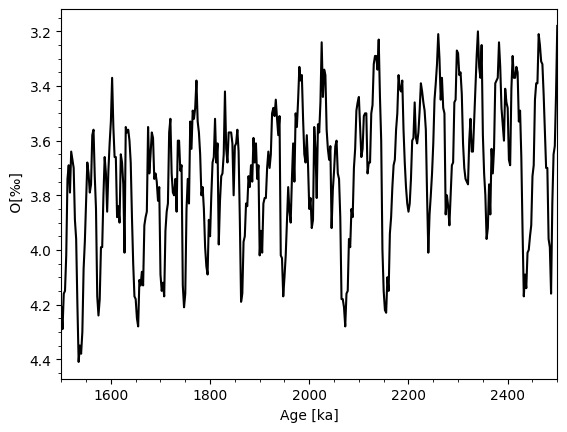

In [24]:
plt.plot(age, d180,'k')
plt.xlabel('Age [ka]')
plt.ylabel(r' O[‰]')
plt.gca().invert_yaxis()
plt.xlim([1500,2500])
plt.minorticks_on()

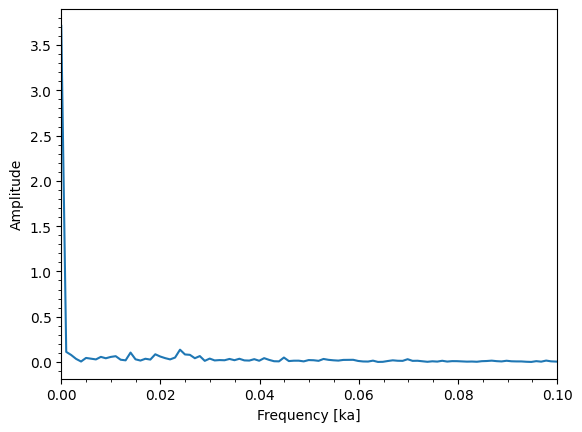

In [25]:
freqs, amps = freq_spectrum(age, d18O) #calculate the frequency spectrum
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [ka]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

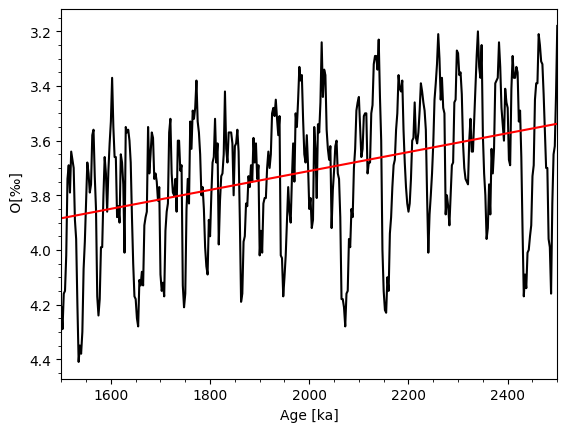

In [26]:
pp = np.polyfit(age,d18O,1) #fit a trendline to the data
plt.plot(age,d18O,'k') #plot the original data
plt.plot(age,np.polyval(pp,age),'r') #plot the trendline
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r' O[‰]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([1500,2500]) #limit the x-axis
plt.minorticks_on() #add minorticks

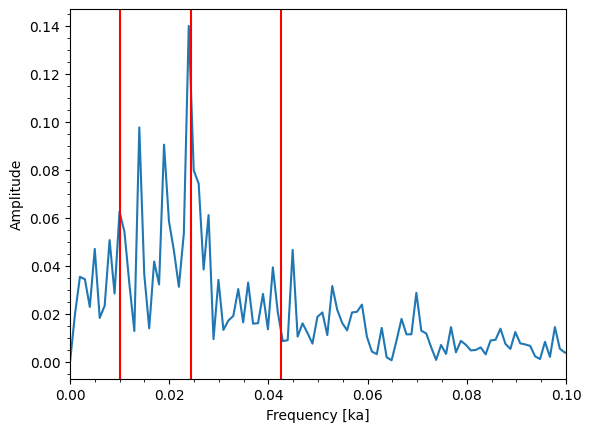

In [27]:
detrend = d18O-np.polyval(pp,age) #calculate the detrended data
freqs, amps = freq_spectrum(age,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [ka]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

plt.gca().axvline(x=1/100,color='r') #mark eccentricity frequency
plt.gca().axvline(x=1/41,color='r') #mark obliquity frequency
plt.gca().axvline(x=1/23.5,color='r') #mark precession frequency

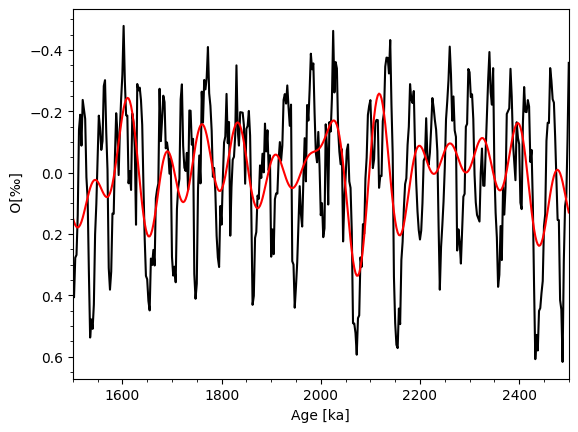

In [28]:
plt.plot(age,detrend,'k') #plot the detrended data
x, y = lowpass_filter(age,detrend,1/70) #obtain the filtered signal
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r' O[‰]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([1500,2500]) #limit the x-axis
plt.minorticks_on() #add minorticks